# Dataset Description: Credit Card Fraud Detection

This dataset contains transactions made by credit cards. It includes anonymized features along with transaction details used for fraud detection.

---

## 🔹 Column-wise Description

### 🕒 Time
- Represents the time elapsed (in seconds) since the first transaction in the dataset  
- Useful for time-based feature engineering (e.g., transaction patterns over time)

---

### 🔢 V1 to V28 (Anonymized Features)
- These are transformed features obtained using PCA (Principal Component Analysis)
- Original features are hidden due to confidentiality reasons
- These variables capture underlying patterns in transaction behavior

👉 Important:
- These features are already scaled
- Cannot directly interpret them (black-box features)

---

### 💰 Amount
- Transaction amount
- Not scaled initially
- Important for detecting abnormal or high-value fraud transactions

---

### 🎯 Class (Target Variable)
- Binary variable indicating fraud status:
  - **0 → Normal Transaction**
  - **1 → Fraudulent Transaction**

👉 Key Insight:
- Highly imbalanced dataset (fraud cases are very rare)

---

## 📊 Summary

- Total Columns: 31  
- Features: 30  
- Target Variable: 1 (Class)  
- Dataset Type: Imbalanced Classification Problem  

---

## ⚠️ Important Characteristics

- Most features are PCA transformed → low interpretability  
- Severe class imbalance → requires special handling (SMOTE, Precision-Recall focus)  
- Real-world fraud detection scenario  


# Step 1: Import Libraries and Load the Data

In this step, we import required libraries and load the dataset.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r"C:\Users\ASUS\Desktop\Real-Time-Credit-Card-Fraud-Detection-Risk-Scoring-System\data\raw_dataset.csv")
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


# Step 2: Basic Understanding

- df.info()
- df.shape
- df.size

In [4]:
df.info()
df.shape
df.size

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


69988820

# Step 3: Check Duplicates

In [5]:
df.duplicated().sum()

np.int64(0)

# Step 4: Check Anomalies

In [6]:
df.isin(['?', '/', '--']).sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

# Step 5: Data Types

In [7]:
df.dtypes

step                int64
type               object
amount            float64
nameOrig           object
oldbalanceOrg     float64
newbalanceOrig    float64
nameDest           object
oldbalanceDest    float64
newbalanceDest    float64
isFraud             int64
isFlaggedFraud      int64
dtype: object

# Step 6: Check Missing Values

- Drop columns >40% null
- Drop rows <5% null
- Numeric: mean/median
- Categorical: mode

In [8]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

# Step 7: Check Outliers (IQR, Z-score)

In [9]:
Q1 = df['amount'].quantile(0.25)
Q3 = df['amount'].quantile(0.75)
IQR = Q3 - Q1

outliers = df[(df['amount'] < (Q1 - 1.5 * IQR)) | (df['amount'] > (Q3 + 1.5 * IQR))]
len(outliers)

338078

# Step 8: Feature Engineering

- Balance difference features

In [10]:
df['balance_diff_orig'] = df['oldbalanceOrg'] - df['newbalanceOrig']
df['balance_diff_dest'] = df['newbalanceDest'] - df['oldbalanceDest']

# Step 9: Separate Numerical and Categorical Columns

In [11]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

num_cols, cat_cols

(Index(['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest',
        'newbalanceDest', 'isFraud', 'isFlaggedFraud', 'balance_diff_orig',
        'balance_diff_dest'],
       dtype='object'),
 Index(['type', 'nameOrig', 'nameDest'], dtype='object'))

# Step 10: Statistical Summary

- Mean vs Median
- Skewness understanding

In [12]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
step,6362620.0,2.433972e+02,1.423320e+02,1.00,156.00,239.000,3.350000e+02,7.430000e+02
amount,6362620.0,1.798619e+05,6.038582e+05,0.00,13389.57,74871.940,2.087215e+05,9.244552e+07
oldbalanceOrg,6362620.0,8.338831e+05,2.888243e+06,0.00,0.00,14208.000,1.073152e+05,5.958504e+07
newbalanceOrig,6362620.0,8.551137e+05,2.924049e+06,0.00,0.00,0.000,1.442584e+05,4.958504e+07
oldbalanceDest,6362620.0,1.100702e+06,3.399180e+06,0.00,0.00,132705.665,9.430367e+05,3.560159e+08
newbalanceDest,6362620.0,1.224996e+06,3.674129e+06,0.00,0.00,214661.440,1.111909e+06,3.561793e+08
isFraud,6362620.0,1.290820e-03,3.590480e-02,0.00,0.00,0.000,0.000000e+00,1.000000e+00
isFlaggedFraud,6362620.0,2.514687e-06,1.585775e-03,0.00,0.00,0.000,0.000000e+00,1.000000e+00
balance_diff_orig,6362620.0,-2.123056e+04,1.466433e+05,-1915267.90,0.00,0.000,1.015044e+04,1.000000e+07
balance_diff_dest,6362620.0,1.242947e+05,8.129391e+05,-13060826.21,0.00,0.000,1.491054e+05,1.056878e+08


In [13]:
df[num_cols].skew()

step                   0.375177
amount                30.993949
oldbalanceOrg          5.249136
newbalanceOrig         5.176884
oldbalanceDest        19.921758
newbalanceDest        19.352302
isFraud               27.779538
isFlaggedFraud       630.603629
balance_diff_orig     24.630520
balance_diff_dest     32.916341
dtype: float64

# Sampling Large Dataset for Efficient Analysis

Due to large dataset size (~6M rows), we take a representative sample for efficient analysis.

In [16]:
df_sample = df.sample(n=100000, random_state=42)
df_sample.shape

(100000, 13)

# Step 11: Univariate Analysis (All Numerical Columns)

- Metrics: skewness, kurtosis
- Plots: Histplot, Boxplot, KDE
- Using subplot + loop for all numeric features

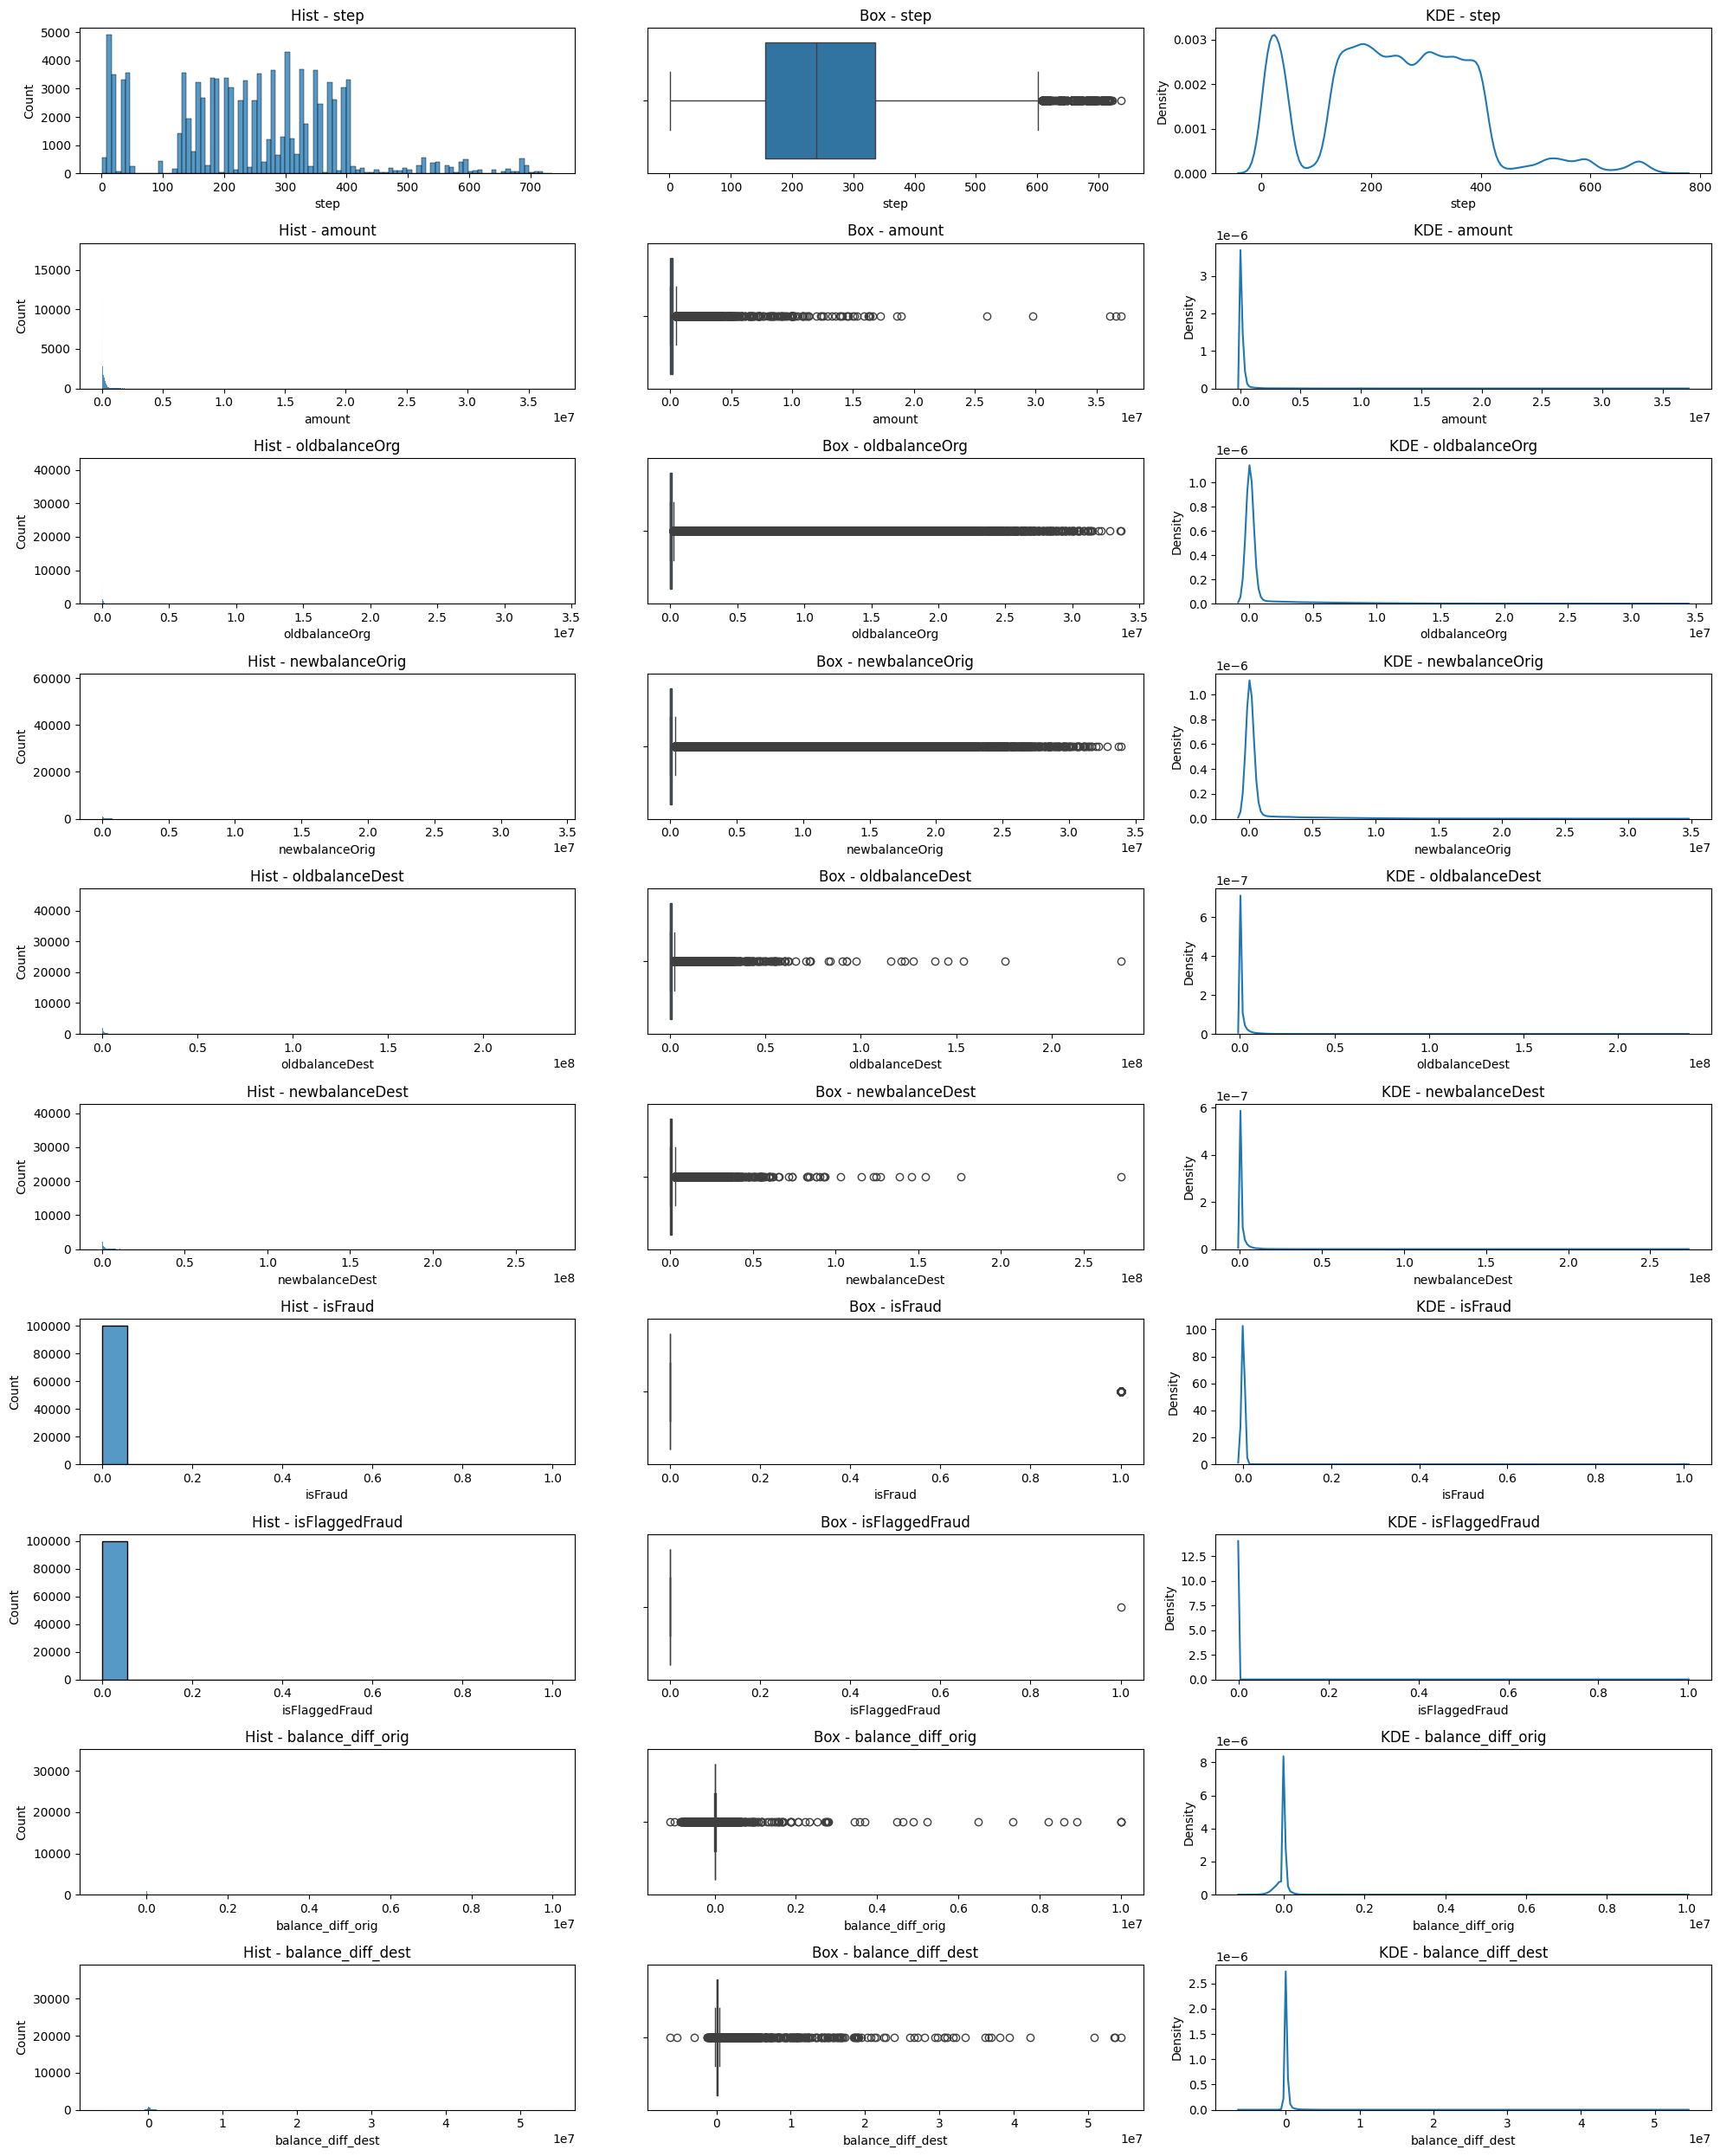

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = df_sample.select_dtypes(include=['int64', 'float64']).columns

plt.rcParams['figure.figsize'] = (20, 25)

fig, axes = plt.subplots(len(num_cols), 3)

for i, col in enumerate(num_cols):
    
    sns.histplot(df_sample[col], ax=axes[i,0])
    axes[i,0].set_title(f'Hist - {col}')
    
    sns.boxplot(x=df_sample[col], ax=axes[i,1])
    axes[i,1].set_title(f'Box - {col}')
    
    sns.kdeplot(df_sample[col], ax=axes[i,2])
    axes[i,2].set_title(f'KDE - {col}')

plt.tight_layout()
plt.show()

# Step 11: Bivariate Analysis

- Numeric vs Target (isFraud)
- Using boxplots across all numerical columns

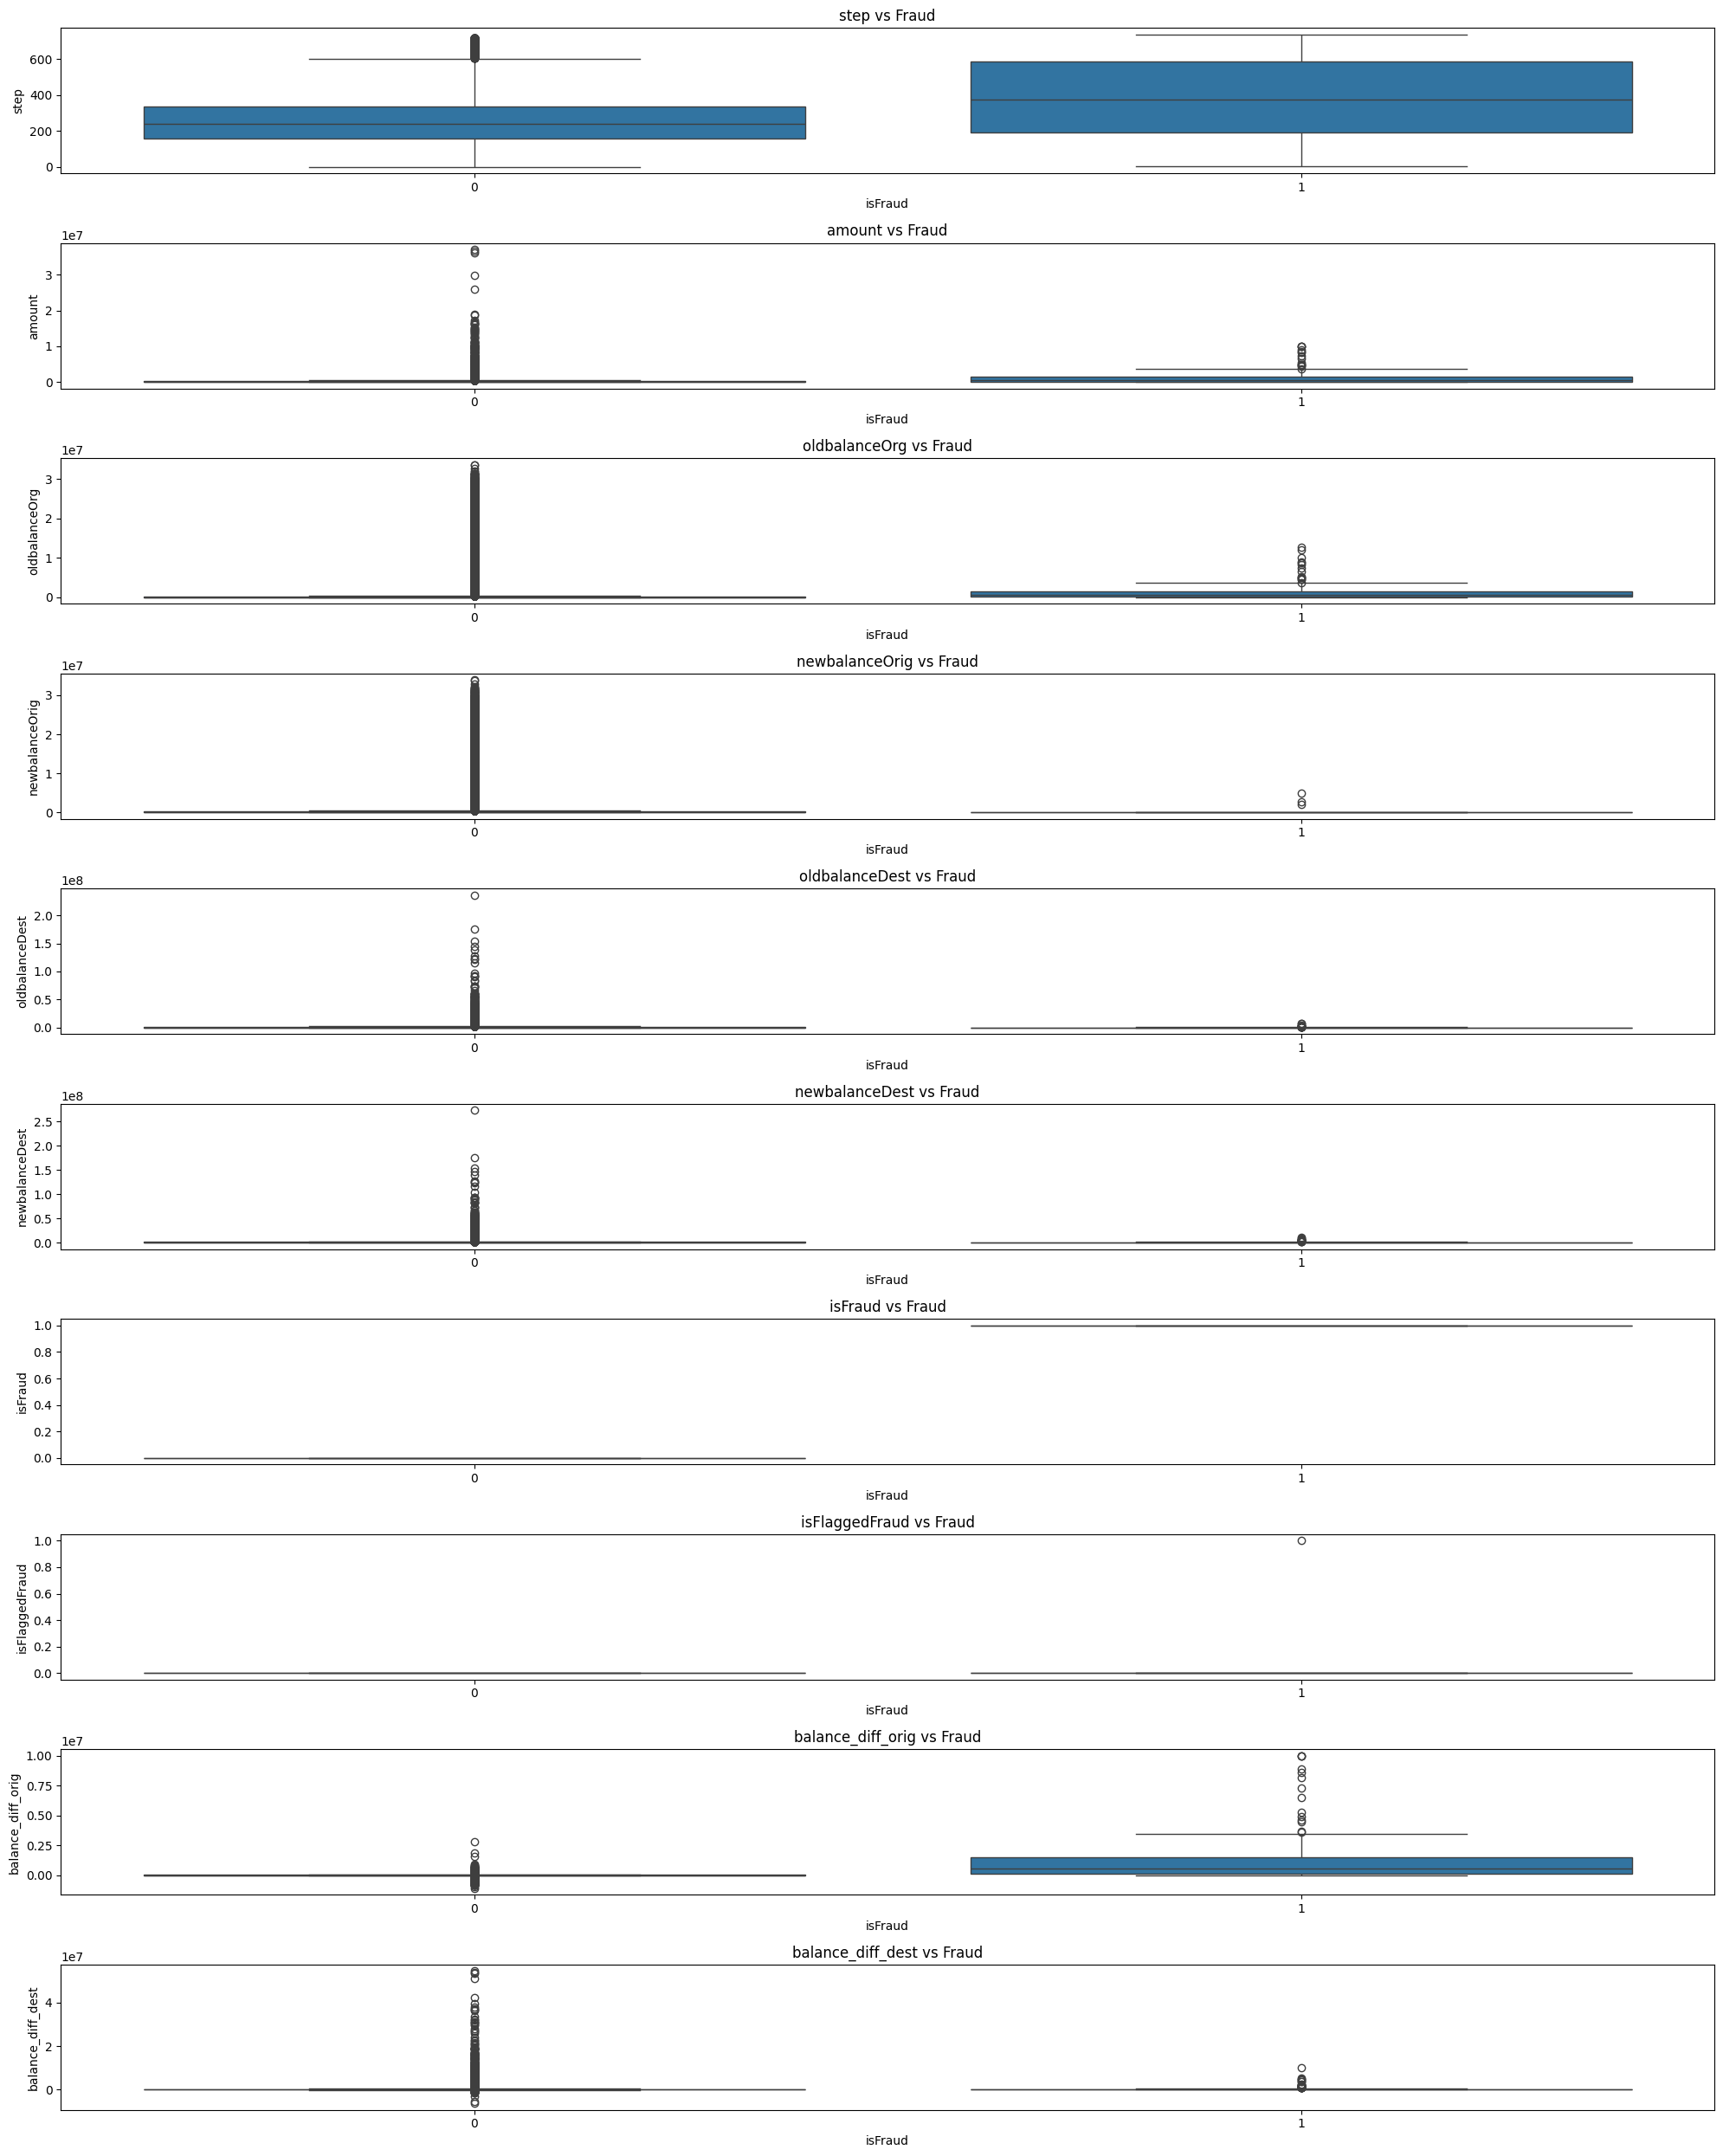

In [18]:
plt.rcParams['figure.figsize'] = (20, 25)

fig, axes = plt.subplots(len(num_cols), 1)

for i, col in enumerate(num_cols):
    sns.boxplot(x='isFraud', y=col, data=df_sample, ax=axes[i])
    axes[i].set_title(f'{col} vs Fraud')

plt.tight_layout()
plt.show()

# Step 11: Categorical vs Target Analysis

C:\Users\ASUS\AppData\Local\Temp\ipykernel_30420\3721614685.py:11: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
c:\Users\ASUS\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


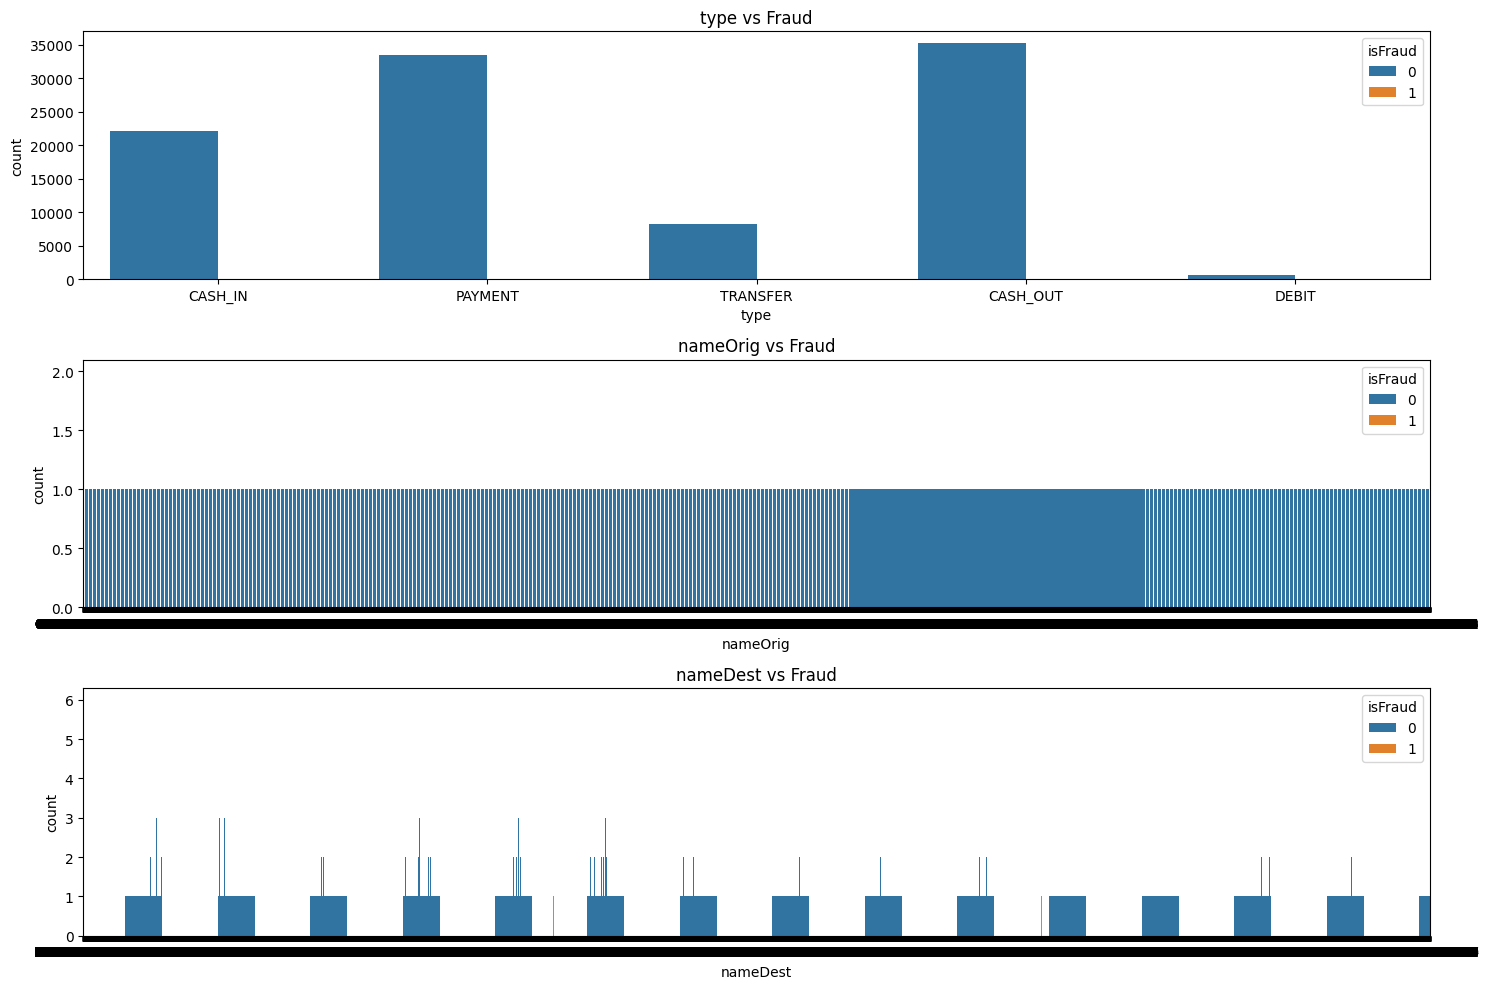

In [19]:
cat_cols = df_sample.select_dtypes(include=['object']).columns

plt.rcParams['figure.figsize'] = (15, 10)

fig, axes = plt.subplots(len(cat_cols), 1)

for i, col in enumerate(cat_cols):
    sns.countplot(x=col, hue='isFraud', data=df_sample, ax=axes[i])
    axes[i].set_title(f'{col} vs Fraud')

plt.tight_layout()
plt.show()

# Step 11: Multivariate Analysis

- Correlation heatmap
- Pairplot for key features

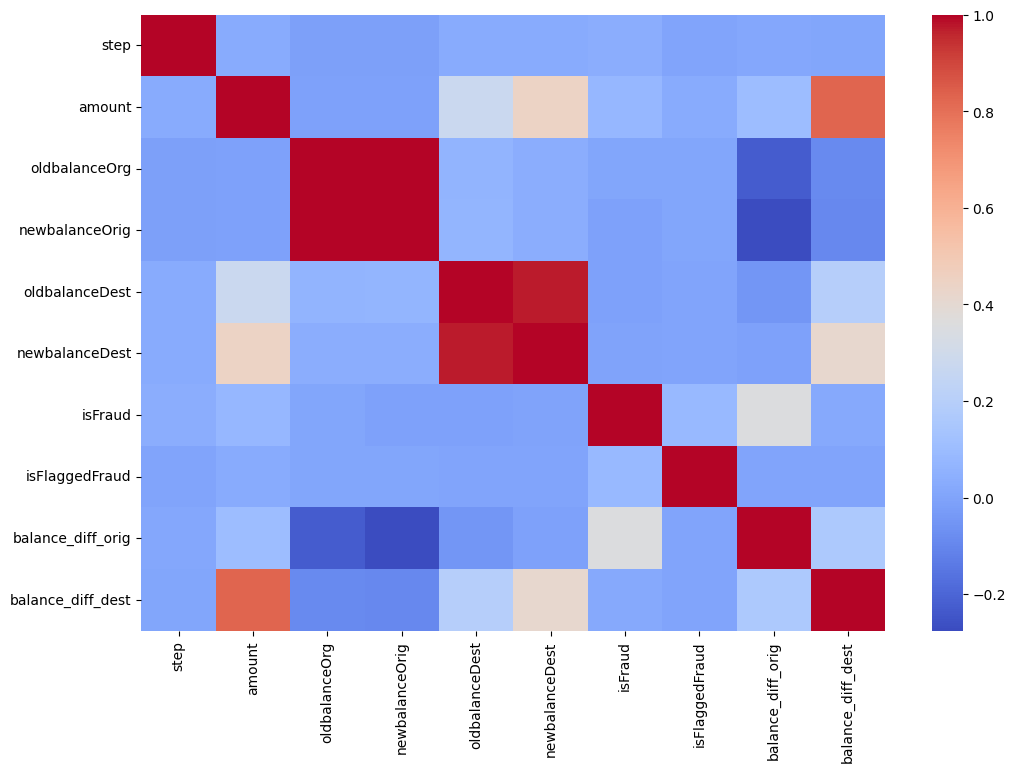

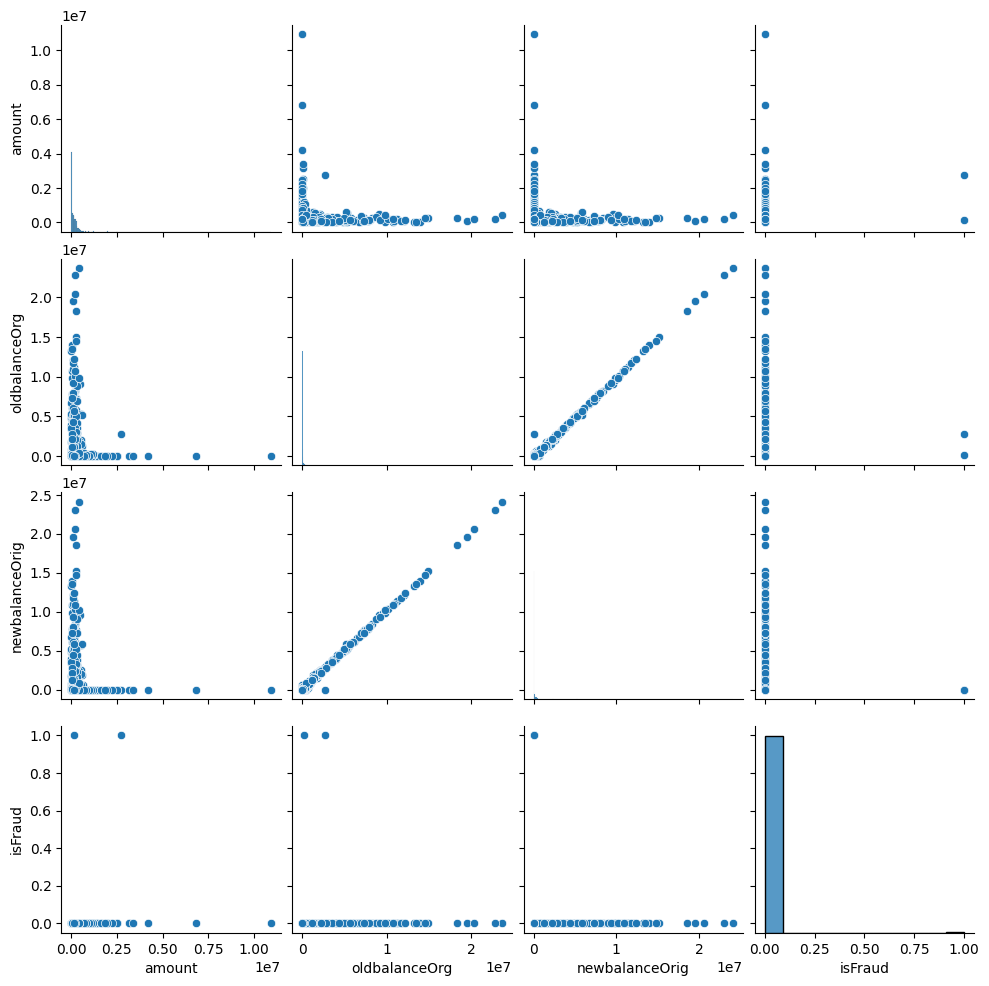

In [20]:
corr = df_sample.corr(numeric_only=True)

plt.figure(figsize=(12,8))
sns.heatmap(corr, cmap='coolwarm')
plt.show()

sns.pairplot(df_sample.sample(1000)[['amount','oldbalanceOrg','newbalanceOrig','isFraud']])
plt.show()

In [21]:
df.to_csv('../data/cleaned_paysim_data.csv', index=False)